# AI534 Implementation Assignment 2###

**Team Members**:
Manogna Challoju,
Shanmukha Rangeneni

**Deadline**: Sunday, Oct. 27, by 11:59pm

**Submission**: Submit 1) your completed notebook in ipynb format, and 2) a PDF export of the completed notebook with outputs.

**Late Submission**: Please see the syllabus for the late submission policy.

In this assignment, we will implement and experiment with logistic regression with L2 and L1 regularization to predict whether a health insurance customer will purchase car insurance as well based on a set of features.

You may modify the starter code as you see fit, including changing the signatures of functions and adding/removing helper functions. However, please make sure that your TA can understand what you are doing and why.

First lets import the necessary packages.

In [75]:
!pip install nbconvert > /dev/null 2>&1
!pip install pdfkit > /dev/null 2>&1
!apt-get install -y wkhtmltopdf > /dev/null 2>&1
import os
import pdfkit
import contextlib
import sys
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import StandardScaler
# add more imports if necessary

# Loading data and perform feature normalization for numerical features

---

On canvas, we have provided three different data files for this assignment: IA2-train.csv (for training), IA2-dev.csv(for validation) and IA2-train-noisy.csv (for noisy training). Download them and upload them to your google drive. Then mount the google drive from your google colab notebook:


In [76]:
from google.colab import drive
drive.mount('/content/gdrive')

train_path = '/content/gdrive/My Drive/AI534/IA2-train.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path
val_path = '/content/gdrive/My Drive/AI534/IA2-dev.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path
noisy_data_path = '/content/gdrive/My Drive/AI534/IA2-train-noisy.csv' # DO NOT MODIFY THIS. Please make sure your data has this exact path

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


You have one additional preprocessing step to do, which is to perform feature normalization (z-score) for 3 numerical features ("Age", "Annual_Premium", "Vintage").

In [77]:
raw_train_data = pd.read_csv(train_path)
raw_val_data = pd.read_csv(val_path)
raw_noisy_data = pd.read_csv(noisy_data_path)

# features selected for normalization
features_normalised = ["Age", "Annual_Premium", "Vintage"]

# Standardizing the data
scaler = StandardScaler()
raw_train_data[features_normalised] = scaler.fit_transform(raw_train_data[features_normalised])
raw_val_data[features_normalised] = scaler.fit_transform(raw_val_data[features_normalised])
raw_noisy_data[features_normalised] = scaler.fit_transform(raw_noisy_data[features_normalised])

# Print DataFrame which is normalised
display(raw_train_data.head())


label_col_name = 'Response'

# Split the data in training, validation and noisy data
X_train_data = raw_train_data.drop(columns=[label_col_name])
y_train_data = raw_train_data[label_col_name]

X_val_data = raw_val_data.drop(columns=[label_col_name])
y_val_data = raw_val_data[label_col_name]

X_noisy_data = raw_noisy_data.drop(columns=[label_col_name])
y_noisy_data = raw_noisy_data[label_col_name]

print("X_train_data_data Shape:", X_train_data.shape)
print("y_train_data_data Shape:", y_train_data.shape)
print("X_val_data Shape:", X_val_data.shape)
print("y_val_data Shape:", y_val_data.shape)
print("X_noisy_data Shape:", X_noisy_data.shape)
print("y_noisy_data Shape:", y_noisy_data.shape)

,dummy,Gender,Age,Driving_License,Previously_Insured,Vehicle_Damage,Annual_Premium,Vintage,Region_Code_0,Region_Code_1,...,Policy_Sales_Channel_153,Policy_Sales_Channel_154,Policy_Sales_Channel_155,Policy_Sales_Channel_156,Policy_Sales_Channel_157,Policy_Sales_Channel_158,Policy_Sales_Channel_159,Policy_Sales_Channel_160,Policy_Sales_Channel_163,Response
0,1,1,-1.171946,1,0,1,-1.605302,0.382120,0,0,...,0,0,0,1,0,0,0,0,0,1
1,1,0,0.242608,1,0,1,1.488306,-0.060282,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,-0.606125,1,0,1,1.103908,0.394077,0,0,...,0,0,0,0,0,0,0,0,0,1
3,1,1,1.091340,1,0,1,0.844486,-0.789649,0,0,...,0,0,0,0,0,0,0,0,0,1
4,1,1,-0.606125,1,0,1,-1.605302,0.860394,0,0,...,0,0,0,0,0,0,0,0,0,1


X_train_data_data Shape: (6000, 197)
y_train_data_data Shape: (6000,)
X_val_data Shape: (10000, 197)
y_val_data Shape: (10000,)
X_noisy_data Shape: (6000, 197)
y_noisy_data Shape: (6000,)


# Part 1 (35 pts) Logstic regression with L2 (Ridge) regularization

For this part of the assignment, you will implement and experiment with Logistic regression with L2 regularization (Algorithm 1 in Assignment 2 Reference Information on canvas).


## Impelement Logistic regression with L2 regularization
As a recommendation, your implemented function should consider the following inputs:
1. The training data
2. The regularization parameter $\lambda$
3. The learning rate
4. Max iterations (recommend to start with 5000)
5. Threshold for change in loss (this will be used for early stopping: if the change in loss is less than the threshold, it is considered to have converged. Please use a threhold of $10^{-7}$. )

Your function should output the learned weight vector. But it is also a good idea to output the sequence of losses so that you can visualize the convergence process to ensure proper convergence. You should also implement a divergence detection, if the loss starts to diverge, terminate and raise an alarm.



In [78]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def L2_regularization(X, y, reg_exp, learning_rate, max_itrs, threshold):
    # Weight initialisation
    num_rows, num_cols = X.shape
    weight_vector = np.zeros(num_cols)
    losses = []

    # gradient descent computation
    for i in range(max_itrs):
        scores = np.dot(X, weight_vector)
        predictions = sigmoid(scores)
        reg_term = reg_exp * np.sum(weight_vector ** 2) ## loss calculation starts here
        loss = np.mean(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions)) + reg_term
        losses.append(loss)
        gradient = np.dot(X.T, (predictions - y)) / num_rows + 2 * reg_exp * weight_vector
        weight_vector = weight_vector - (learning_rate * gradient) # updating weight

        # Checking convergence
        if i > 0 and abs(losses[i] - losses[i-1]) < threshold:
            print(f"Converged acheived during iteration {i}.")
            break

        # Checking divergence
        if i > 0 and losses[i] > losses[i-1]:
            raise ValueError("Divergence identified. It's advisable to change the learning rate or regularization factor.")

    return weight_vector, losses


##Experiment with different regularization parameters
For this part, you will need to run your L2 logistic regression algorithm on the training data with different regularization parameters $\lambda\in \{10^i: i\in[-5, 0]\}$. This is the minimim range of values required. Feel free to experiment with more extreme or in-between values to help you answer the questions.

**Learning Rate Tuning Guidelines:**
For different values of $\lambda$, you'll need to adjust the learning rate. I recommend starting with $\gamma = 1$ for very small $\lambda$s (e.g. $10^{-5}, 10^{-4}$). For moderately larger $\lambda$ values like $10^{-3}$, consider a smaller learning rate like $\gamma = 0.1$. As $\lambda$ increases further, you will need to continue decreasig the learning rate accordingly.
Note: You might wonder why larger $\lambda$ values require a smaller learning rate. This is because larger $\lambda$ values increase the strength of regularization, which in turn affects the gradient due to the larger penalty term (related to the regularization term). If the same learning rate is used, it can result in larger update steps due to the increased gradient magnitude, potentially leading to unstable training.

For each $\lambda$ value, you are required to run the logistic regression to convergence, record the resulting model (the weight vector), evaluate it on the training and validation data and record the accuracies.

In [79]:

results = {}

reg_params = [10**i for i in range(-5, 1)]
learning_rates = {1e-5: 1, 1e-4: 1, 1e-3: 0.1, 1e-2: 0.01, 1e-1: 0.001, 1: 0.0001}

for reg_exp in reg_params:
    learning_rate = learning_rates[min(learning_rates, key=lambda x: abs(x - reg_exp))]

    #Running L2 regularization
    weights, loss= L2_regularization(X_train_data, y_train_data, reg_exp, learning_rate, max_itrs=5000, threshold=1e-7)
    #Training data and test data evaluation
    train_data_scores = np.dot(X_train_data,weights)
    train_data_predictions = sigmoid(train_data_scores) > 0.5
    train_data_accuracy = np.mean(train_data_predictions == y_train_data)
    val_data_scores = np.dot(X_val_data,weights)
    val_data_predictions = sigmoid(val_data_scores) > 0.5
    val_data_accuracy = np.mean(val_data_predictions == y_val_data)

    results[reg_exp] = {'weights': weights, 'loss': loss, 'train_data_accuracy': train_data_accuracy, 'val_data_accuracy': val_data_accuracy}

for reg_exp, result in results.items():
    print(f"Lambda: {reg_exp}, Train Accuracy: {result['train_data_accuracy']}, Validation Accuracy: {result['val_data_accuracy']}")


Converged acheived during iteration 3436.
Converged acheived during iteration 4600.
Lambda: 1e-05, Train Accuracy: 0.8011666666666667, Validation Accuracy: 0.7926
Lambda: 0.0001, Train Accuracy: 0.8011666666666667, Validation Accuracy: 0.7935
Lambda: 0.001, Train Accuracy: 0.795, Validation Accuracy: 0.7936
Lambda: 0.01, Train Accuracy: 0.7825, Validation Accuracy: 0.7846
Lambda: 0.1, Train Accuracy: 0.7613333333333333, Validation Accuracy: 0.763
Lambda: 1, Train Accuracy: 0.7158333333333333, Validation Accuracy: 0.72


### 1.1 Impact on training and validation accuracy

Plot the training accuracy and validation accuracy of the learned L2 regularized logistic regression model as a function of $\lambda$.
When plotting, use a logarithmic scale for the x-axis to represent $\lambda$. In other words, each tick mark on the x-axis should correspond to a unique integar $i$ and be labeled as $10^{-i}$. This will allow us to better visualize how the model performance changes across different orders of magnitude for $\lambda$.  

Please plot the two curves in the same figure using different colors for easy comparison. Provide clear legend to indicate which curve is which.

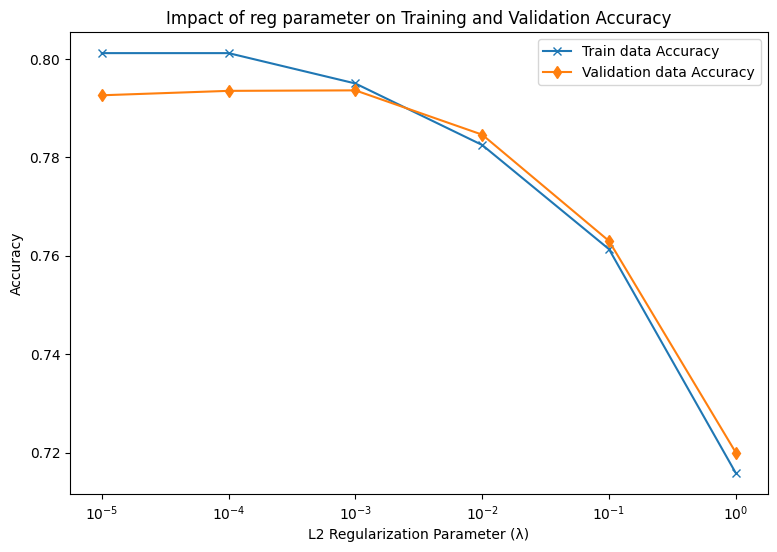

In [80]:
values = [np.log10(reg_exp) for reg_exp in results.keys()]
train_data_accuracies = [result['train_data_accuracy'] for result in results.values()]
val_data_accuracies = [result['val_data_accuracy'] for result in results.values()]
plt.figure(figsize=(9, 6))
plt.plot(values, train_data_accuracies, label='Train data Accuracy', marker='x')
plt.plot(values, val_data_accuracies, label='Validation data Accuracy', marker='d')

# plotting training and validation accuracy
plt.title('Impact of reg parameter on Training and Validation Accuracy', fontsize=12)
plt.xlabel('L2 Regularization Parameter (λ)', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.xticks(values, [f'$10^{{{int(i)}}}$' for i in values])
plt.legend()
plt.show()

**Question**

(a) Which $\lambda$ value leads to the best training and validation accuracy respectively? Which one should you use if you are to pick a model for deployment?

(b) What trend do you observe for the training and validation accuracy respectively as we increae $\lambda$? Provide your explanation for this observed trend.


a. λ =0.0001, gives the highest training accuracy at about 0.8011, while the best lambda for validation accuracy is 0.001, which has an accuracy of 0.7936. However, when selecting a model for deployment, it's usually better to choose the one that performs best on the validation set, as this suggests it will work well with new unseen data. So, I will go with λ = 0.001.

b.As the lambda value increases from 10^-5 to 0.0001, both training and validation accuracy improve. This is because a little bit of regularization helps prevent overfitting, leading to better performance on the validation set. However, when lambda goes beyond 0.0001, both training and validation accuracy start to drop. This happens because higher lambda values apply stronger regularization, which can make the model too simple and unable to learn the important patterns in the data.


###1.2 Impact on feature weight_vector
For each value of $\lambda$, present the top five features based on the magnitude of their weight_vector $|w_j|$, excluding the bias term $w_0$. Organize your results into a table. Each column should be dedicated to a specific $\lambda$ value, and rows should indicate the rank of the feature. Ensure that each cell in the table contains both the feature name and its corresponding weight $w_j$.

For example:

| Rank  | $\lambda = 10^{-4}$      | $\lambda = 10^{-3}$      | $\lambda = 10^{-2}$      |
|-------|--------------------------|--------------------------|--------------------------|
| 1     | feature_a, 0.8           | feature_b, 0.7           | feature_c, 0.6           |
| 2     | feature_d, 0.7           | feature_e, 0.6           | feature_f, 0.5           |
| 3     | feature_g, 0.6           | feature_h, 0.5           | feature_i, 0.4           |
| 4     | feature_j, 0.5           | feature_k, 0.4           | feature_l, 0.3           |
| 5     | feature_m, 0.4           | feature_n, 0.3           | feature_o, 0.2           |

The easiest way is to create a dataframe for this table and print the dataframe.

In [81]:
extracted_feature_weights = {
f"λ = {reg_exp}": result.get('weights', [])[1:]
for reg_exp, result in results.items() if 'weights' in result
}

results[reg_exp] = {'weights': weights, 'loss': loss, 'train_data_accuracy': train_data_accuracy, 'val_data_accuracy': val_data_accuracy}
# Creating a DataFrame from extracted feature weights
df = pd.DataFrame(extracted_feature_weights)

# Get top 5 features based on the absolute values for each lambda column
top_features_df = pd.DataFrame({
col: [f"{feat}, {abs(df.loc[feat, col]):.6f}" for feat in df[col].abs().nlargest(5).index]
for col in df.columns
}, index=[f"Rank {i+1}" for i in range(5)])

display(top_features_df)

,λ = 1e-05,λ = 0.0001,λ = 0.001,λ = 0.01,λ = 0.1,λ = 1
Rank 1,"3, 3.265310","3, 3.082633","3, 2.331265","3, 1.271682","3, 0.326361","3, 0.040135"
Rank 2,"4, 2.270865","4, 2.214261","4, 1.937466","4, 1.139679","4, 0.297828","4, 0.039837"
Rank 3,"194, 1.899374","194, 1.775197","194, 1.053553","186, 0.480163","186, 0.163911","1, 0.024774"
Rank 4,"76, 1.434729","76, 0.936337","186, 0.711270","61, 0.445676","61, 0.163192","61, 0.024252"
Rank 5,"41, 1.202497","186, 0.880852","61, 0.587914","2, 0.245162","1, 0.089934","186, 0.023225"


**Question**

1. Do you observe any difference is the top features with different $\lambda$ values?
2. Do you observe any difference in the weight_vector of the top features for different $\lambda$ values?
3. Please provide your own explanation/interpretation of the observed differences.

1. Features show similar values across different lambda values, and they are consistently ranked from 1 to 5 for all lambda values.

2. Top features weights change evidently when lambda changes. For instance, the weight of the top-ranked feature decreases as lambda increases from 10^-5 to 1. This is expected with L2 regularization, which penalises the size of all feature coefficients as lambda goes up. In my case, the weights get smaller as lambda increases.

3. As per my observation, top features stay the same across different lambda values which shows that the model thinks these features are important, but their importance is changed by regularization. As lambda increases, the weights of all features decrease more sharply, indicating that the model favors a simpler approach with less influence from individual features.

  When lambda is lower, the model keeps more information from the features because it imposes a smaller penalty on the coefficients, resulting in larger absolute weights. L2 regularization generally reduces the size of all feature coefficients, and the choice of lambda helps balance the model's complexity with its ability to fit the data.

###1.3 sparsity of weight_vector

For each different value of $\lambda$, compute the sparsity of the learned classifier as the number of feature weight_vector that approxmately equal zero ($\leq 10^{-6}$) and report the sparsity number for each $\lambda$ value.

In [ ]:
sparsity = {}
threshold = 1e-6

for reg_exp, result in results.items():
    weights = result.get('weights', [])[1:]
    sparse_count = sum(abs(w) <= threshold for w in weights)
    sparsity[f"λ = {reg_exp}"] = sparse_count

# Convert sparsity data to a DataFrame
sparsity_df = pd.DataFrame(list(sparsity.items()), columns=["Lambda", "Sparsity"])
display(sparsity_df)

,Lambda,Sparsity
0,λ = 1e-05,47
1,λ = 0.0001,47
2,λ = 0.001,47
3,λ = 0.01,47
4,λ = 0.1,47
5,λ = 1,50


**Question**

1. When we have very small $\lambda$ values (aka very weak regularization), does your learned model have zero weight_vector for some features?  If so, why would it be that way?
2. What trend do you observe for the sparsity of the model as we increase $\lambda$? If we further increase $\lambda$ to even larger values, what do you expect to happen to the sparsity value? Why?


1. Very small λ values mean that the regularization penalty applied to the feature weights is minimal. This allows the weights to remain non-zero. As a result, the model can utilize all the features to adapt to the data, which may cause overfitting.

2. As we increase λ, the sparsity of the model tends to increase, meaning that more feature weights become zero. If we keep increasing λ to even higher values, we expect the sparsity to keep increasing. This happens because larger λ values apply a stronger penalty to the weights, pushing more of them towards zero. So, the model ends up using fewer features to make predictions.

# Part 2. (40 pts) Logistic regression with L1 regularization.

In this part, we will repeat the part 1 but with L1 regularization. Please refer to the algorithm 2 in the Assignment 2 Reference Information file for the details of the algorithm.

## Impelement Logistic regression with L1 regularization
As a recommendation, your implemented function should consider the following inputs:
1. The training data
2. The regularization parameter $\lambda$
3. The learning rate
4. Max iterations (recommend to start with 5000)
5. Threshold for change in loss (this will be used for early stopping: if the change in loss is less than the threshold, it is considered to have converged. Please use a threshold of $10^{-7}$. )

Your function should output the learned weight vector. But it is also a good idea to output the sequence of losses so that you can visualize the convergence process.
You should also implement a divergence detection, if the loss starts to diverge, terminate and raise an alarm.


In [82]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def L1_regularization(X, y, reg_exp, learning_rate, max_itrs, threshold):
    # Weight initialisation
    num_rows, num_cols = X.shape
    weight_vector = np.zeros(num_cols)
    losses = []

    # gradient descent computation
    for i in range(max_itrs):
        scores = np.dot(X, weight_vector)
        predictions = sigmoid(scores)
        reg_term = reg_exp * np.sum(np.abs(weight_vector)) ## loss calculation starts here
        loss = np.mean(-y * np.log(predictions) - (1 - y) * np.log(1 - predictions)) + reg_term
        losses.append(loss)
        gradient = np.dot(X.T, (predictions - y)) / num_rows + reg_exp * np.sign(weight_vector)
        weight_vector = weight_vector - (learning_rate * gradient) # updating weight

        # Checking convergence
        if i > 0 and abs(losses[i] - losses[i-1]) < threshold:
            print(f"Converged acheived during iteration {i}.")
            break

        # Checking divergence and alter the parameters
        if i > 0 and losses[i] > losses[i-1]:
            print(f"Divergence identified at {i}. Modify learning rate and re-running with lambda={reg_exp}.")
            learning_rate *= 0.5
            weight_vector = np.zeros(num_cols)
            continue

    return weight_vector, losses


##Experiment with different regularization parameters
For this part, you will need to run your L1 logistic regression algorithm on the training data with different regularization parameters $\lambda\in \{10^i: i\in[-6, -1]\}$. You are welcome to experiment with more extreme or in-between values to help you answer the questions. But be advised using larger $\lambda$ values in this case makes it difficult to converge.

**Learning Rate Tuning Guidelines:**
For L1 regularization, I recommend starting with $\gamma = 2$ for very small $\lambda$s like $10^{-6}, 10^{-5}$, and decreasing the learning for larger $\lambda$ values.

For each $\lambda$ value, you are required to run L1 logistic regression to convergence, record the resulting model (weight_vector), evaluate it on the training and validation data, and record the accuracies.

In [83]:

L1_results = {}

reg_params = [10**i for i in range(-6, 0)]
learning_rates = {1e-6: 2, 1e-5: 2, 1e-4: 1, 1e-3: 0.5, 1e-2: 0.1, 1e-1: 0.01}

for reg_exp in reg_params:
    learning_rate = learning_rates[min(learning_rates, key=lambda x: abs(x - reg_exp))]

    #Running L1 regularization
    weights, loss= L1_regularization(X_train_data, y_train_data, reg_exp, learning_rate, max_itrs=5000, threshold=1e-7)
    #Training data and test data evaluation
    train_data_scores = np.dot(X_train_data,weights)
    train_data_predictions = sigmoid(train_data_scores) > 0.5
    train_data_accuracy = np.mean(train_data_predictions == y_train_data)
    val_data_scores = np.dot(X_val_data,weights)
    val_data_predictions = sigmoid(val_data_scores) > 0.5
    val_data_accuracy = np.mean(val_data_predictions == y_val_data)

    L1_results[reg_exp] = {'weights': weights, 'loss': loss, 'train_data_accuracy': train_data_accuracy, 'val_data_accuracy': val_data_accuracy}

for reg_exp, result in L1_results.items():
    print(f"Lambda: {reg_exp}, Train Accuracy: {result['train_data_accuracy']}, Validation Accuracy: {result['val_data_accuracy']}")


Converged acheived during iteration 2992.
Divergence identified at 429. Modify learning rate and re-running with lambda=0.001.
Divergence identified at 430. Modify learning rate and re-running with lambda=0.001.
Converged acheived during iteration 431.
Divergence identified at 231. Modify learning rate and re-running with lambda=0.01.
Divergence identified at 232. Modify learning rate and re-running with lambda=0.01.
Converged acheived during iteration 233.
Divergence identified at 1. Modify learning rate and re-running with lambda=0.1.
Divergence identified at 3. Modify learning rate and re-running with lambda=0.1.
Divergence identified at 5. Modify learning rate and re-running with lambda=0.1.
Divergence identified at 7. Modify learning rate and re-running with lambda=0.1.
Divergence identified at 9. Modify learning rate and re-running with lambda=0.1.
Divergence identified at 11. Modify learning rate and re-running with lambda=0.1.
Divergence identified at 13. Modify learning rate a

### 2.1 Impact on training/validation accuracy, and sensitivity to regularization parameter
Plot the training accuracy and validation accuracy of the learned L1 regularized logistic regression model as a function of $\lambda$. When plotting, use a logarithmic scale for the x-axis to represent $\lambda$. In other words, each tick mark on the x-axis should correspond to a unique integar $i$ and be labeled as  $10^{−i}$ . This will allow us to better visualize how the model performance changes across different orders of magnitude for $\lambda$.

Please plot the two curves in the same figure using different colors for easy comparison. Provide clear legend to indicate which curve is which.

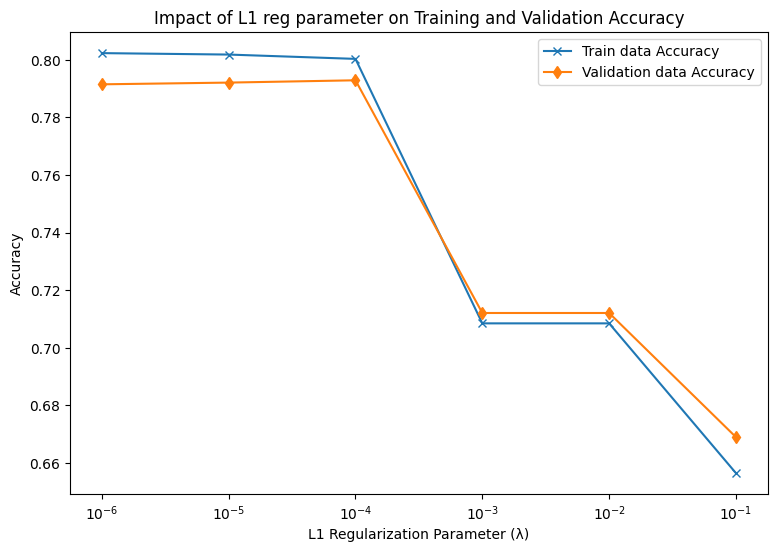

In [ ]:
L1_values = [np.log10(reg_exp) for reg_exp in L1_results.keys()]
L1_train_data_accuracies = [result['train_data_accuracy'] for result in L1_results.values()]
L1_val_data_accuracies = [result['val_data_accuracy'] for result in L1_results.values()]
plt.figure(figsize=(9, 6))
plt.plot(L1_values, L1_train_data_accuracies, label='Train data Accuracy', marker='x')
plt.plot(L1_values, L1_val_data_accuracies, label='Validation data Accuracy', marker='d')

# Setting plot title and labels
plt.title('Impact of L1 reg parameter on Training and Validation Accuracy', fontsize=12)
plt.xlabel('L1 Regularization Parameter (λ)', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.xticks(L1_values, [f'$10^{{{int(i)}}}$' for i in L1_values])
plt.legend()
plt.show()

**Question**

(a) For L1 LR, which $\lambda$ value leads to the best training and validatoin accuracy respectively? Which one should you use if you are to pick a model for deployment?

(b) What trend do you observe for the training and validation accuracy respectively as we increae $\lambda$? Provide your explanation for this observed trend.

(c) Comparing L1 and L2 regularized logistic regression, which one is more sensitive to the choice of the regularization parameter? An algorithm is considered sensitive to the regularization parameter if the model's performance or the values of its learned parameters change significantly with variations in the regularization parameter. Given that your experiments explored a smaller range of $\lambda$ values for L1 regularization due to convergence concern, you may use an off-the-shelf implementation (e.g., from scikit-learn) to explore this comparison more effectively. Reflect on the differences you observe (or expect to observe) between L1 and L2 in terms of sensitivity to the regularization parameter, and explain why.


a) λ value that gives the best training accuracy is 1e-6
 , with a training accuracy of 0.8023. The λ value for the best validation accuracy is 0.0001, with an accuracy of 0.7929. As mentioned earlier, it’s better to select the model that works best on the validation set. So, I select using λ=0.0001, as it is likely to perform well on new, unseen data.

b) As λ increases from 1e-6 to 0.001, both training and validation accuracy decrease slightly. This happens because a small amount of regularization helps the model generalize better to the validation set than having no regularization at all. However, when λ goes beyond 0.001, both accuracies continue to drop, indicating that too much regularization can hurt the model's performance.

  Additionally, we can see that the training accuracy is always higher than the validation accuracy for all values of λ. This is because the model is designed to fit the training data as closely as possible.

c) L1 regularized logistic regression is more sensitive to the choice of the regularization parameter λ compared to L2. This means that small changes in λ can significantly affect the model's performance and which features are included. L1 can push some weights to zero, making it more variable, while L2 keeps all weights non-zero and tends to lead to smoother and more stable performance across different λ values. I noticed that L1 requires more careful tuning of λ to get good results, while L2 performs consistently better across a wider range of λ values.

###2.2 Impact on feature weight_vector
For each value of $\lambda$, present the top five features based on the magnitude of their weight_vector $|w_j|$, excluding the bias term $w_0$. Organize your results into a table. Each column should be dedicated to a specific $\lambda$ value, and rows should indicate the rank of the feature. Ensure that each cell in the table contains both the feature name and its corresponding weight $w_j$.

For example:

| Rank  | $\lambda = 10^{-4}$      | $\lambda = 10^{-3}$      | $\lambda = 10^{-2}$      |
|-------|--------------------------|--------------------------|--------------------------|
| 1     | feature_a, 0.8           | feature_b, 0.7           | feature_c, 0.6           |
| 2     | feature_d, 0.7           | feature_e, 0.6           | feature_f, 0.5           |
| 3     | feature_g, 0.6           | feature_h, 0.5           | feature_i, 0.4           |
| 4     | feature_j, 0.5           | feature_k, 0.4           | feature_l, 0.3           |
| 5     | feature_m, 0.4           | feature_n, 0.3           | feature_o, 0.2           |

In [84]:
L1_extracted_feature_weights = {
f"λ = {reg_exp}": result.get('weights', [])[1:]
for reg_exp, result in L1_results.items() if 'weights' in result
}

L1_results[reg_exp] = {'weights': weights, 'loss': loss, 'train_data_accuracy': train_data_accuracy, 'val_data_accuracy': val_data_accuracy}
# Creating a DataFrame from extracted feature weights
df = pd.DataFrame(L1_extracted_feature_weights)

# Get top 5 features based on the absolute values for each lambda column
L1_top_features_df = pd.DataFrame({
col: [f"{feat}, {abs(df.loc[feat, col]):.6f}" for feat in df[col].abs().nlargest(5).index]
for col in df.columns
}, index=[f"Rank {i+1}" for i in range(5)])

display(L1_top_features_df)

,λ = 1e-06,λ = 1e-05,λ = 0.0001,λ = 0.001,λ = 0.01,λ = 0.1
Rank 1,"3, 3.284653","3, 3.280571","3, 3.250696","4, 0.016604","4, 0.003321","4, 0.000000"
Rank 2,"4, 2.295564","4, 2.292361","4, 2.238615","3, 0.016260","3, 0.003252","3, 0.000000"
Rank 3,"76, 1.940427","76, 1.911496","194, 1.910380","1, 0.011021","1, 0.002204","73, 0.000000"
Rank 4,"194, 1.890441","194, 1.900106","76, 0.957786","61, 0.010073","61, 0.002015","112, 0.000000"
Rank 5,"41, 1.391572","41, 1.368433","186, 0.945828","186, 0.009594","186, 0.001919","50, 0.000000"


**Question**

1. Do you observe any difference is the top features with different $\lambda$ values?
2. Do you observe any difference in the weight_vector of the top features for different $\lambda$ values?
3. Please provide your own explanation/interpretation of the observed differences.
4. What are some differences for this part of the results comparing L1 and L2 regularization? Provide your own explanation for such differences.


1. Yes, based on the observations, there is a difference in the top features with different λ values. While some feature indices, such as 3, 4, and 76, consistently appear across various λ values, their rankings and relative importance change. This indicates that as λ varies, the model assigns different levels of importance to each feature, affecting which features are most influential in the model's predictions.

2. Yes, there are small differences in the weights of the top features for different λ values. The weights change slightly, which shows that the regularization is affecting the importance of certain features, but only a little.

3. The observed differences suggest that as I change λ, the model adjusts how much it emphasizes or ignores certain features. With a smaller λ, the model fits more closely to the data, keeping more features important. But with a larger λ, the model becomes more selective, focusing only on a few key features and reducing the influence of others. This helps in simplifying the model when needed.

4. In L1 regularization, the weights of less important features are pushed exactly to zero, meaning the model ignores these features completely. This results in a "sparse" model that only keeps the most important features. On the other hand, L2 regularization reduces the weights of less important features but keeps them small instead of setting them to zero, so it includes more features in the model.

The main difference is that L1 creates a simpler, more selective model by ignoring certain features, while L2 keeps all features but with reduced influence. However, L1 can sometimes struggle to stabilize in certain cases, making the model less reliable in those situations.

###2.3 Sparsity of weight_vector

For each different value of $\lambda$, compute the sparsity of the learned L1 regularized logistic regression classifier as the number of feature weight_vector that approxmately equal zero ($\leq 10^{-6}$) and report the sparsity number for each $\lambda$ value.

In [85]:
sparsity = {}
threshold = 1e-6

for reg_exp, result in L1_results.items():
    weights = result.get('weights', [])[1:]
    sparse_count = sum(abs(w) <= threshold for w in weights)
    sparsity[f"λ = {reg_exp}"] = sparse_count

sparsity_df = pd.DataFrame(list(sparsity.items()), columns=["Lambda", "Sparsity"])
display(sparsity_df)

,Lambda,Sparsity
0,λ = 1e-06,48
1,λ = 1e-05,48
2,λ = 0.0001,47
3,λ = 0.001,60
4,λ = 0.01,60
5,λ = 0.1,196


**Question**

1. What trend do you observe for the sparsity of the L1 regularized model as we change $\lambda$? If we further increase $\lambda$, what do you expect? Why?
2. What are some differences for this part of the results comparing L1 and L2 regularization? Provide your own explanation for such differences.


1. As the values of λ increase, the sparsity of the L1 regularized model also increases. This trend is very clear from the provided results. For smaller λ values, the sparsity is 48, while for slightly larger λ values (0.0001 and 0.001), the sparsity changes to 47 and 60. Moreover, for λ values of 0.01 and 0.1, the sparsity jumps from 60 to 196, indicating an increase as λ increases. Therefore, if we continue to raise the λ value, we would expect to see even higher sparsity.

2. In L1 regularization, less important feature weights are pushed exactly to zero, leading to high sparsity. This makes the model easier to interpret because it only includes the relevant features.
On the other hand, L2 regularization penalizes the square of the weights, allowing them to get close to zero but not reach it. This means that L2 regularization does not enforce sparsity as strictly as L1, keeping more features in the model even if their weights are small.

# Part 3. (25 pts) Impact of Noise
For this part, you will be training both L1 and L2 logistic regression models using the noisy training data. For L2, you should consider the same set of $\lambda$ values as part 1. For L1, you will find it to be extremely difficult to converge to a meaningful solution for $\lambda=0.1$, so you will use the same set of values as part 2 but exclude $\lambda=0.1$.  For each regularization method, please plot the model's training and validation accuracy against the regularization parameter $\lambda$.

Converged acheived during iteration 3609.
Converged acheived during iteration 1054.
Converged acheived during iteration 155.
Converged acheived during iteration 3310.
Divergence identified at 2. Modify learning rate and re-running with lambda=0.01.
Divergence identified at 3. Modify learning rate and re-running with lambda=0.01.
Converged acheived during iteration 4.


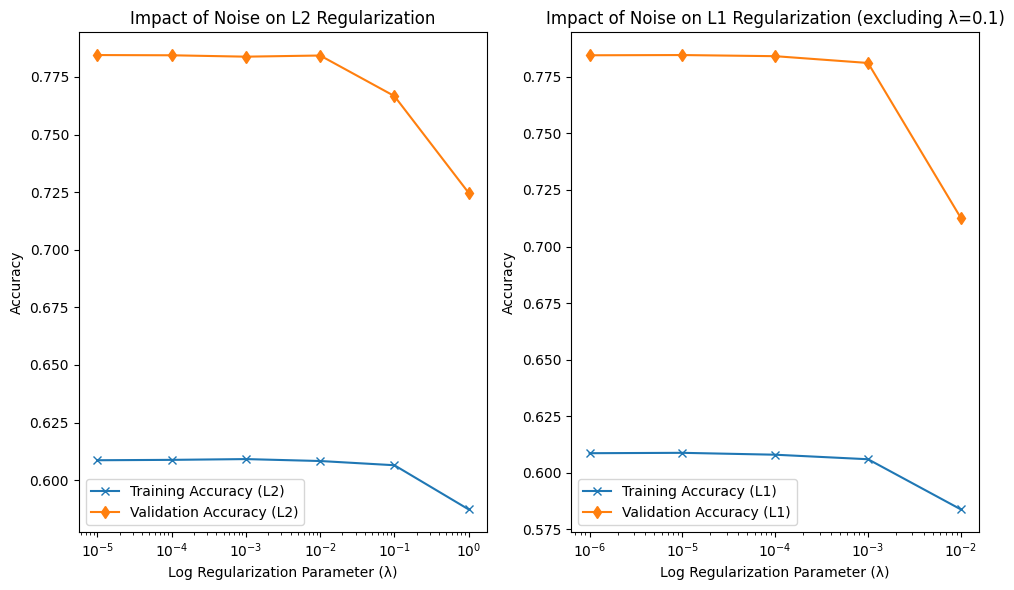

In [ ]:
L1_reg_params = [10**i for i in range(-6, 0) if 10**i != 0.1]
L2_reg_params = [10**i for i in range(-5, 1)]


L2_train_data_accuracy = []
L2_val_data_accuracy = []
L1_train_data_accuracy = []
L1_val_data_accuracy = []

# Run L2 logistic regression
for reg_exp in L2_reg_params:
    weights, _ = L2_regularization(X_noisy_data, y_noisy_data, reg_exp, learning_rate=0.01, max_itrs=5000, threshold=1e-7)
    train_data_scores = np.dot(X_noisy_data, weights)
    train_data_predictions = sigmoid(train_data_scores) > 0.5
    train_data_accuracy = np.mean(train_data_predictions == y_noisy_data)
    L2_train_data_accuracy.append(train_data_accuracy)
    #Evaluate validation
    val_data_scores = np.dot(X_val_data, weights)
    val_data_predictions = sigmoid(val_data_scores) > 0.5
    val_data_accuracy = np.mean(val_data_predictions == y_val_data)
    L2_val_data_accuracy.append(val_data_accuracy)

# Run L1 logistic regression
for reg_exp in L1_reg_params:
    weights, _ = L1_regularization(X_noisy_data, y_noisy_data, reg_exp, learning_rate=0.01, max_itrs=5000, threshold=1e-7)

    # Evaluation on training & validation data
    train_data_scores = np.dot(X_noisy_data, weights)
    train_data_predictions = sigmoid(train_data_scores) > 0.5
    train_data_accuracy = np.mean(train_data_predictions == y_noisy_data)
    L1_train_data_accuracy.append(train_data_accuracy)
    val_data_scores = np.dot(X_val_data, weights)
    val_data_predictions = sigmoid(val_data_scores) > 0.5
    val_data_accuracy = np.mean(val_data_predictions == y_val_data)
    L1_val_data_accuracy.append(val_data_accuracy)

# Plot the results for L2 regularization
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(L2_reg_params, L2_train_data_accuracy, label='L2 Training Accuracy', marker='x')
plt.plot(L2_reg_params, L2_val_data_accuracy, label='L2 Validation Accuracy', marker='d')
plt.xscale('log')
plt.xlabel('Log Regularization Parameter (λ)')
plt.ylabel('Accuracy')
plt.title('Noise Impact on L2 Regularization')
plt.legend()

# Plot the results for L1 regularization
plt.subplot(1, 2, 2)
plt.plot(L1_reg_params, L1_train_data_accuracy, label='L1 Training Accuracy', marker='x')
plt.plot(L1_reg_params, L1_val_data_accuracy, label='L1 Validation Accuracy', marker='d')
plt.xscale('log')
plt.xlabel('Log Regularization Parameter (λ)')
plt.ylabel('Accuracy')
plt.title('Noise Impact on L1 Regularization (excluding λ=0.1)')
plt.legend()

plt.tight_layout()
plt.show()

**Question**
Your experiments should reveal that when trained with the noisy data, both L1 and L2 regulated logistic regression models would have substantially reduced training accuracies, but the validation accuracies will only suffer a mild reduction.  

Here I provide two possible explanations for this phenonmenon:
1. This is due to the use of regularization, which reduces the model's ability to overfit to the noise.
2. This is due to the simplicity of the model, which just could not overfit to the noise very well.

For this case, what do you think is the main cause for the observe phenomenon? Why?

Please design another experiment that will allow you to figure out which of the two possibilities plays a more critical role in the observed phenomenon. **You do not need to run this experiment**, just need to explain the experiment and why it would help answer the question.


I can structure the experiment by first training a logistic regression model on the noisy data without any regularization. This way, the model can overfit the noise in the dataset. Then, I will compare the training and validation accuracies of the regularized model with the model trained without regularization. This comparison will help me see how much regularization reduces overfitting and improves the model's ability to generalize.

Next, I'll look at the differences in training and validation accuracies between the regularized and non-regularized models. If the regularized model shows a smaller drop in training accuracy compared to the non-regularized model, while the validation accuracy stays stable or only decreases a little, this would support the idea that regularization is important for reducing overfitting to noise.

By comparing how well the regularized and non-regularized models perform on the noisy dataset, I can better understand how regularization affects the model's ability to deal with noise and its performance on new data.

# **Bonus. In-class competition (6 bonus pts)**
We will host a in-class competition using the IA2 data. For this competition, you are required to use logistic regression models. To improve your model, you can work on feature engineering (manipulating and changing the features), hyperparameter tuning, different regulerization methods. You could even use off the shelf logistic regression implementations if your own implementation is not efficient.

To participate in this competition, use the following link:
https://www.kaggle.com/t/04f96acd9e764682aaa56cef35830670

You should continue working in the same team for this competition. The training and validation data provided on the kaggle site are the same as the IA2 assignment. To participate, you will need to train your model and apply the trained to the test data provided on kaggle, and submit prediction files to be scored.

Your scoring will have two parts, the performance on the public leader board as well as the private leader board. The results on the public leader board is visible through out the competition so that you can gauge how well your model is performing in comparison to others. The private leader board shows the final evaluation performance and will be released only once after the competition is closed.

Each team will be allowed to submit 3 final entries to be evaluated. You can use the public leaderboard performance to pick which models to use for your final evaluation entries.

Assginment of the bonus points:

Performance bonus: the top 3 teams on the private leader board will recieve 6 bonus points.

Participation bonus: the 3 teams that submitted the most entries (with different performances) will recieve 4.5 bonus points.

Also any team that participated the competition and got non-trivial performance (public leaderboard score >0.78) will receive 3 bonus points.

Bonus points are capped at 6.

**Please provide the team name on the kaggle competition here __IA2 8___. Leave it blank if you opt not to participate.**

In [88]:
#running this code block will convert this notebook and its outputs into a pdf report.
!jupyter nbconvert --to html /content/gdrive/MyDrive/Colab\ Notebooks/IA2-2024.ipynb  # you might need to change this path to appropriate value to location your copy of the IA0 notebook

input_html = '/content/gdrive/MyDrive/Colab Notebooks/IA2-2024.html' #you might need to change this path accordingly
output_pdf = '/content/gdrive/MyDrive/Colab Notebooks/IA2output.pdf' #you might need to change this path or name accordingly

# Convert HTML to PDF
pdfkit.from_file(input_html, output_pdf)

# Download the generated PDF
files.download(output_pdf)

[NbConvertApp] Converting notebook /content/gdrive/MyDrive/Colab Notebooks/IA2-2024.ipynb to html
[NbConvertApp] Writing 947473 bytes to /content/gdrive/MyDrive/Colab Notebooks/IA2-2024.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>